### Problem Statement
##### The restaurant industry relies heavily on customer feedback and engagement to evaluate business performance and customer satisfaction. Online platforms such as Yelp generate large volumes of customer interaction data, including ratings, reviews, tips, and check-ins. However, this raw data is often complex and difficult to interpret without proper analysis.
##### Restaurant owners, analysts, and business stakeholders need a clear understanding of how customer engagement and ratings influence restaurant success. Identifying patterns in customer behavior can help determine which restaurants perform well, which locations have higher customer activity, and how engagement metrics relate to restaurant popularity.
##### The main problem addressed in this project is to analyze restaurant performance and customer engagement using Yelp data in order to identify meaningful patterns and insights. Specifically, the project aims to understand how customer ratings, reviews, tips, and check-ins contribute to restaurant success and how these factors vary across different cities.
##### To address this problem, data analytics techniques were applied using Python for data preparation, SQL for data aggregation, and Power BI for interactive visualization. The resulting dashboard provides a comprehensive view of restaurant performance and customer engagement trends.
 
### Project Objectives
##### The primary objective of this project is to analyze restaurant performance and customer engagement using Yelp data and to transform raw data into meaningful business insights through data analytics techniques.
##### The specific objectives of the project include:
##### 1.	Analyze restaurant performance by examining customer ratings and identifying top-performing restaurants.
##### 2.	Evaluate customer engagement patterns using key interaction metrics such as reviews, tips, and check-ins.
##### 3.	Identify geographic trends by analyzing restaurant distribution and performance across different cities.
##### 4.	Examine the relationship between restaurant ratings and customer engagement to understand how quality influences popularity.
##### 5.	Develop an interactive Power BI dashboard that allows users to explore restaurant performance and customer behavior through visual analytics.
 



### Importing Librabries

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import numpy as np
import sqlite3
import folium
import geopy 
from geopy.geocoders import Nominatim
from matplotlib.colors import LinearSegmentedColormap
from IPython.display import display
import warnings
warnings.filterwarnings('ignore')


### Database connection

In [43]:
# Creating database connection
conn = sqlite3.connect('yelp.db')

In [44]:
tables = pd.read_sql_query("SELECT name from sqlite_master where type = 'table'",conn)

In [45]:
tables

,name
0,business
1,review
2,user
3,tip
4,checkin


In [46]:
#explore what type of data available in the tables
for table in tables['name']:
    display(pd.read_sql_query(f"SELECT * from {table} limit 5",conn))

,business_id,name,address,city,state,postal_code,latitude,longitude,stars,review_count,is_open,categories
0,Pns2l4eNsfO8kk83dixA6A,"Abby Rappoport, LAC, CMQ","1616 Chapala St, Ste 2",Santa Barbara,CA,93101,34.426679,-119.711197,5.0,7,0,"Doctors, Traditional Chinese Medicine, Naturop..."
1,mpf3x-BjTdTEA3yCZrAYPw,The UPS Store,87 Grasso Plaza Shopping Center,Affton,MO,63123,38.551126,-90.335695,3.0,15,1,"Shipping Centers, Local Services, Notaries, Ma..."
2,tUFrWirKiKi_TAnsVWINQQ,Target,5255 E Broadway Blvd,Tucson,AZ,85711,32.223236,-110.880452,3.5,22,0,"Department Stores, Shopping, Fashion, Home & G..."
3,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,1,"Restaurants, Food, Bubble Tea, Coffee & Tea, B..."
4,mWMc6_wTdE0EUBKIGXDVfA,Perkiomen Valley Brewery,101 Walnut St,Green Lane,PA,18054,40.338183,-75.471659,4.5,13,1,"Brewpubs, Breweries, Food"


,review_id,user_id,business_id,stars,useful,funny,cool,text,date
0,KU_O5udG6zpxOg-VcAEodg,mh_-eMZ6K5RLWhZyISBhwA,XQfwVwDr-v0ZS3_CbbE5Xw,3.0,0,0,0,"If you decide to eat here, just be aware it is...",2018-07-07 22:09:11
1,BiTunyQ73aT9WBnpR9DZGw,OyoGAe7OKpv6SyGZT5g77Q,7ATYjTIgM3jUlt4UM3IypQ,5.0,1,0,1,I've taken a lot of spin classes over the year...,2012-01-03 15:28:18
2,saUsX_uimxRlCVr67Z4Jig,8g_iMtfSiwikVnbP2etR0A,YjUWPpI6HXG530lwP-fb2A,3.0,0,0,0,Family diner. Had the buffet. Eclectic assortm...,2014-02-05 20:30:30
3,AqPFMleE6RsU23_auESxiA,_7bHUi9Uuf5__HHc_Q8guQ,kxX2SOes4o-D3ZQBkiMRfA,5.0,1,0,1,"Wow! Yummy, different, delicious. Our favo...",2015-01-04 00:01:03
4,Sx8TMOWLNuJBWer-0pcmoA,bcjbaE6dDog4jkNY91ncLQ,e4Vwtrqf-wpJfwesgvdgxQ,4.0,1,0,1,Cute interior and owner (?) gave us tour of up...,2017-01-14 20:54:15


,user_id,name,review_count,yelping_since,useful,funny,cool,elite,friends,fans,...,compliment_more,compliment_profile,compliment_cute,compliment_list,compliment_note,compliment_plain,compliment_cool,compliment_funny,compliment_writer,compliment_photos
0,qVc8ODYU5SZjKXVBgXdI7w,Walker,585,2007-01-25 16:47:26,7217,1259,5994,2007,"NSCy54eWehBJyZdG2iE84w, pe42u7DcCH2QmI81NX-8qA...",267,...,65,55,56,18,232,844,467,467,239,180
1,j14WgRoU_-2ZE1aw1dXrJg,Daniel,4333,2009-01-25 04:35:42,43091,13066,27281,"2009,2010,2011,2012,2013,2014,2015,2016,2017,2...","ueRPE0CX75ePGMqOFVj6IQ, 52oH4DrRvzzl8wh5UXyU0A...",3138,...,264,184,157,251,1847,7054,3131,3131,1521,1946
2,2WnXYQFK0hXEoTxPtV2zvg,Steph,665,2008-07-25 10:41:00,2086,1010,1003,"2009,2010,2011,2012,2013","LuO3Bn4f3rlhyHIaNfTlnA, j9B4XdHUhDfTKVecyWQgyA...",52,...,13,10,17,3,66,96,119,119,35,18
3,SZDeASXq7o05mMNLshsdIA,Gwen,224,2005-11-29 04:38:33,512,330,299,"2009,2010,2011","enx1vVPnfdNUdPho6PH_wg, 4wOcvMLtU6a9Lslggq74Vg...",28,...,4,1,6,2,12,16,26,26,10,9
4,hA5lMy-EnncsH4JoR-hFGQ,Karen,79,2007-01-05 19:40:59,29,15,7,,"PBK4q9KEEBHhFvSXCUirIw, 3FWPpM7KU1gXeOM_ZbYMbA...",1,...,1,0,0,0,1,1,0,0,0,0


,user_id,business_id,text,date,compliment_count
0,AGNUgVwnZUey3gcPCJ76iw,3uLgwr0qeCNMjKenHJwPGQ,Avengers time with the ladies.,2012-05-18 02:17:21,0
1,NBN4MgHP9D3cw--SnauTkA,QoezRbYQncpRqyrLH6Iqjg,They have lots of good deserts and tasty cuban...,2013-02-05 18:35:10,0
2,-copOvldyKh1qr-vzkDEvw,MYoRNLb5chwjQe3c_k37Gg,It's open even when you think it isn't,2013-08-18 00:56:08,0
3,FjMQVZjSqY8syIO-53KFKw,hV-bABTK-glh5wj31ps_Jw,Very decent fried chicken,2017-06-27 23:05:38,0
4,ld0AperBXk1h6UbqmM80zw,_uN0OudeJ3Zl_tf6nxg5ww,Appetizers.. platter special for lunch,2012-10-06 19:43:09,0


,business_id,date
0,---kPU91CF4Lq2-WlRu9Lw,"2020-03-13 21:10:56, 2020-06-02 22:18:06, 2020..."
1,--0iUa4sNDFiZFrAdIWhZQ,"2010-09-13 21:43:09, 2011-05-04 23:08:15, 2011..."
2,--30_8IhuyMHbSOcNWd6DQ,"2013-06-14 23:29:17, 2014-08-13 23:20:22"
3,--7PUidqRWpRSpXebiyxTg,"2011-02-15 17:12:00, 2011-07-28 02:46:10, 2012..."
4,--7jw19RH9JKXgFohspgQw,"2014-04-21 20:42:11, 2014-04-28 21:04:46, 2014..."


### Data Analysis

In [47]:
pd.read_sql_query("Select count(*) from business",conn)

,count(*)
0,150346


##### business_id for those business which is open and category like restaurant.

In [48]:
business_id = pd.read_sql_query("Select business_id, review_count from business where lower(categories) like '%restaurant%' and is_open = 1",conn)

In [49]:
# What is the descriptive stats for review count and star rating for businesses?
## avg, min, max, medain

pd.read_sql_query(f"""Select avg(review_count) as avg_review_count, 
min(review_count) as min_review_count, 
max(review_count) as max_review_count,
(Select review_count from business order by review_count limit 1 offset (Select count(*) from business)/2) as median_review_count
,
AVG(stars) as avg_star_rating,
min(stars) as min_star_rating,
max(stars) as max_star_rating,
(Select stars From business ORDER BY stars LIMIT 1 OFFSET (Select count(*) from business) /2 ) as median_star_rating

from business 
where business_id IN {tuple(business_id['business_id'])}""",conn).transpose()

,0
avg_review_count,104.097789
min_review_count,5.000000
max_review_count,7568.000000
median_review_count,15.000000
avg_star_rating,3.523969
min_star_rating,1.000000
max_star_rating,5.000000
median_star_rating,3.500000


In [50]:
business_id

,business_id,review_count
0,MTSW4McQd7CbVtyjqoe9mw,80
1,CF33F8-E6oudUQ46HnavjQ,6
2,bBDDEgkFA1Otx9Lfe7BZUQ,10
3,eEOYSgkmpB90uNA7lDOMRA,10
4,il_Ro8jwPlHresjw9EGmBg,28
...,...,...
34999,w_4xUt-1AyY2ZwKtnjW0Xg,998
35000,l9eLGG9ZKpLJzboZq-9LRQ,11
35001,cM6V90ExQD6KMSU3rRB5ZA,33
35002,WnT9NIzQgLlILjPT0kEcsQ,35


In [51]:
def remove_outliers(df, col):
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]
    return df

In [52]:
business_id = remove_outliers(business_id, 'review_count')

In [53]:
business_id.shape

(31537, 2)

In [54]:
## query after outlires remove form the review_count

# What is the descriptive stats for review count and star rating for businesses?
## avg, min, max, medain

pd.read_sql_query(f"""Select avg(review_count) as avg_review_count, 
min(review_count) as min_review_count, 
max(review_count) as max_review_count,
(Select review_count from business order by review_count limit 1 offset (Select count(*) from business)/2) as median_review_count
,
AVG(stars) as avg_star_rating,
min(stars) as min_star_rating,
max(stars) as max_star_rating,
(Select stars From business ORDER BY stars LIMIT 1 OFFSET (Select count(*) from business) /2 ) as median_star_rating

from business 
where business_id IN {tuple(business_id['business_id'])}""",conn).transpose()

,0
avg_review_count,55.975426
min_review_count,5.000000
max_review_count,248.000000
median_review_count,15.000000
avg_star_rating,3.477281
min_star_rating,1.000000
max_star_rating,5.000000
median_star_rating,3.500000


In [55]:
# Which resturants have the higest no. of reviews?

pd.read_sql_query(f"""Select name, sum(review_count) as review_count, avg(stars) as avg_rating
from business
where business_id IN {tuple(business_id['business_id'])}
group by name 
order by review_count desc
limit 10""",conn)

,name,review_count,avg_rating
0,McDonald's,16490,1.868702
1,Chipotle Mexican Grill,9071,2.381757
2,Taco Bell,8017,2.141813
3,Chick-fil-A,7687,3.377419
4,First Watch,6761,3.875000
5,Panera Bread,6613,2.661905
6,Buffalo Wild Wings,6483,2.344828
7,Domino's Pizza,6091,2.290210
8,Wendy's,5930,2.030159
9,Chili's,5744,2.514706


##### Most restaurants fall within moderate review ranges

##### A few restaurants dominate with very high review counts

In [56]:
# Which resturants have the higest no. of rating?

pd.read_sql_query(f"""Select name, sum(review_count) as review_count, avg(stars) as avg_rating
from business
where business_id IN {tuple(business_id['business_id'])}
group by name 
order by avg_rating desc
limit 10""",conn)

,name,review_count,avg_rating
0,ā café,48,5.0
1,two birds cafe,77,5.0
2,the brewers cabinet production,13,5.0
3,taqueria la cañada,17,5.0
4,la bamba,44,5.0
5,la 5th av tacos,24,5.0
6,el sabor mexican and chinese food,21,5.0
7,eat.drink.Om...YOGA CAFE,7,5.0
8,d4 Tabletop Gaming Cafe,8,5.0
9,cabbage vegetarian cafe,12,5.0


##### Popularity ≠ Quality. Volume-driven businesses score poorly; niche local restaurants score perfectly but lack volume.

In [57]:
# Do resturant with higher engagement ted to have higher ratings?

pd.read_sql_query("""Select business_id,
sum(length(date) - length(replace(date,',',''))+1) as checkin_count
from checkin
group by business_id

""",conn)



,business_id,checkin_count
0,---kPU91CF4Lq2-WlRu9Lw,11
1,--0iUa4sNDFiZFrAdIWhZQ,10
2,--30_8IhuyMHbSOcNWd6DQ,2
3,--7PUidqRWpRSpXebiyxTg,10
4,--7jw19RH9JKXgFohspgQw,26
...,...,...
131925,zznJox6-nmXlGYNWgTDwQQ,67
131926,zznZqH9CiAznbkV6fXyHWA,1
131927,zzu6_r3DxBJuXcjnOYVdTw,23
131928,zzw66H6hVjXQEt0Js3Mo4A,2


In [58]:
pd.read_sql_query("""Select business_id,count(*)
from tip
group by business_id
 """,conn)

,business_id,count(*)
0,---kPU91CF4Lq2-WlRu9Lw,4
1,--0iUa4sNDFiZFrAdIWhZQ,6
2,--30_8IhuyMHbSOcNWd6DQ,1
3,--7PUidqRWpRSpXebiyxTg,3
4,--8IbOsAAxjKRoYsBFL-PA,4
...,...,...
106188,zzjCxn89a7RQo8keIOO_Ag,1
106189,zzjFdJwXuxBOGe9JeY_EMw,2
106190,zznJox6-nmXlGYNWgTDwQQ,6
106191,zzu6_r3DxBJuXcjnOYVdTw,2


In [59]:
review_count_df = pd.read_sql_query(f"""Select
total.avg_rating as rating,
AVG(total.review_count) as avg_review_count,
AVG(total.checkin_count) as avg_checkin_count,
AVG(total.tip_count) as avg_tip_count
FROM
(
SELECT
    b.business_id,
    SUM(b.review_count) as review_count,
    SUM(b.stars) as avg_rating,
    sum(length(cc.date) - length(replace(cc.date,',',''))+1) as checkin_count,
    SUM(tip.tip_count) as tip_count
FROM
    business b
LEFT JOIN
    checkin cc ON b.business_id = cc.business_id
LEFT JOIN
    (Select business_id, count(business_id) as tip_count from tip GROUP BY business_id ORDER BY tip_count) as tip on b.business_id = tip.business_id WHERE b.business_id IN {tuple(business_id['business_id'])}
GROUP BY 
    b.business_id
) as total
GROUP BY total.avg_rating
""",conn)

In [60]:
review_count_df

,rating,avg_review_count,avg_checkin_count,avg_tip_count
0,1.0,14.365079,17.518072,2.781513
1,1.5,24.358459,34.480969,3.884654
2,2.0,27.759629,52.386515,4.581058
3,2.5,36.631037,79.349429,6.325225
4,3.0,48.054998,105.970405,8.301950
5,3.5,63.730125,125.781702,10.320786
6,4.0,73.136954,127.139075,11.329362
7,4.5,65.282554,86.177605,8.995201
8,5.0,31.127979,27.545113,4.269082


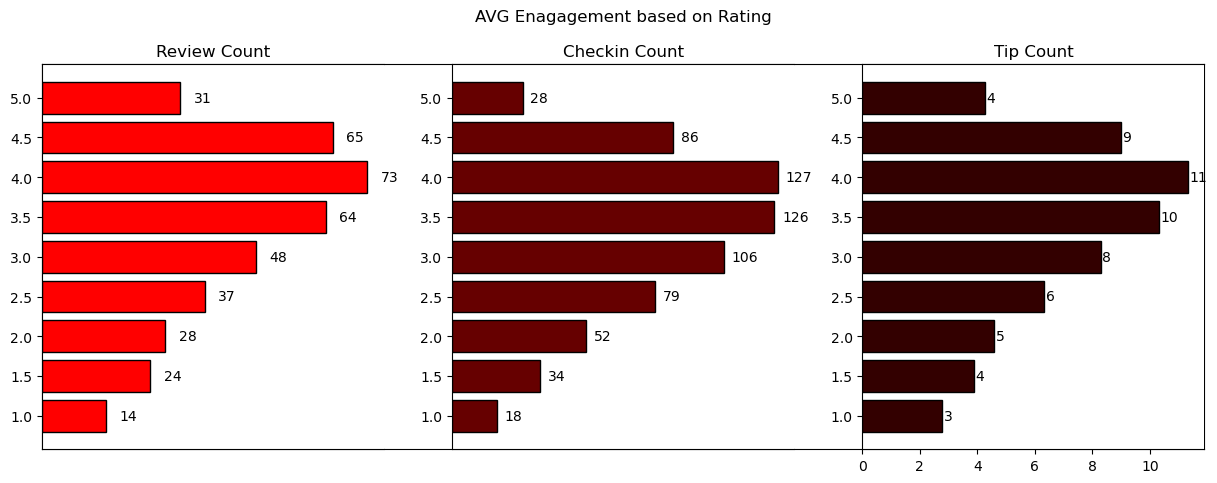

In [61]:
## AVG Enagagement based on Rating

plt.figure(figsize=(15,5))
plt.title("AVG Enagagement based on Rating\n\n")
plt.yticks([])
plt.xticks([])
plt.subplot(1,3,1)
plt.title('Review Count')
plt.barh(review_count_df['rating'].astype('str'), review_count_df['avg_review_count'], edgecolor = 'k', color = '#FF0000')
plt.gca().spines['right'].set_visible(False)
for i, value in enumerate(review_count_df['avg_review_count']):
    plt.text(value+3, i, str(round(value)), color = 'black', va='center')

plt.xticks([])
plt.subplot(1,3,2)
plt.title('Checkin Count')
plt.barh(review_count_df['rating'].astype('str'), review_count_df['avg_checkin_count'], edgecolor = 'k', color = '#660000')
plt.gca().spines['right'].set_visible(False)
for i, value in enumerate(review_count_df['avg_checkin_count']):
    plt.text(value+3, i, str(round(value)), color = 'black', va='center')

plt.xticks([])
plt.subplot(1,3,3)
plt.title('Tip Count')
plt.barh(review_count_df['rating'].astype('str'), review_count_df['avg_tip_count'], edgecolor = 'k', color = '#330000')
plt.gca().spines['right'].set_visible(False)
for i, value in enumerate(review_count_df['avg_tip_count']):
    plt.text(value+0.05, i, str(round(value)), color = 'black', va='center')
   
plt.show()

##### Higher-rated restaurants attract significantly more reviews, check-ins, and tips.

In [62]:
## is there a corealtion between the number of reviews , tips, and check-ins for a business.
engagement_df = pd.read_sql_query(f"""SELECT
    b.business_id,
    SUM(b.review_count) as review_count,
    SUM(b.stars) as avg_rating,
    sum(length(cc.date) - length(replace(cc.date,',',''))+1) as checkin_count,
    SUM(tip.tip_count) as tip_count,
    (Case WHEN b.stars >= 3.5 Then 'High-Rated' ELse 'Low-Rated' END) as category
FROM
    business b
LEFT JOIN
    checkin cc ON b.business_id = cc.business_id
LEFT JOIN
    (Select business_id, count(business_id) as tip_count from tip GROUP BY business_id ORDER BY tip_count) as tip on b.business_id = tip.business_id WHERE b.business_id IN {tuple(business_id['business_id'])}
GROUP BY 
    b.business_id""",conn).dropna()

In [63]:
# Correlation matrix
engagement_df[['review_count','checkin_count','tip_count']].corr()

,review_count,checkin_count,tip_count
review_count,1.000000,0.626884,0.766321
checkin_count,0.626884,1.000000,0.772088
tip_count,0.766321,0.772088,1.000000


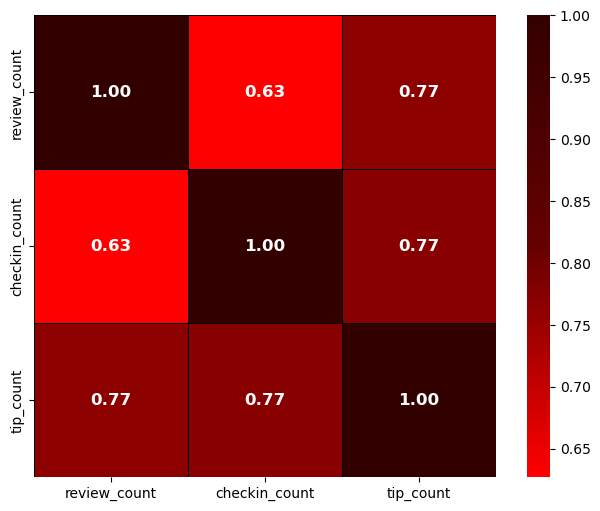

In [89]:



# Compute correlation matrix
corr_matrix = engagement_df[['review_count','checkin_count','tip_count']].corr()

# Define a custom colormap
colors = ['#FF0000', '#660000', '#330000']  # adjust colors if needed
custom_cmap = LinearSegmentedColormap.from_list("nycmap", colors)

# Create heatmap
plt.figure(figsize=(8,6))
ax = sns.heatmap(
    corr_matrix,
    cmap=custom_cmap,
    cbar=True,
    square=True,
    linewidths=0.5,
    linecolor='black'
)

# Manually overlay text annotations for clarity
for i in range(corr_matrix.shape[0]):
    for j in range(corr_matrix.shape[1]):
        ax.text(
            j + 0.5, i + 0.5, f"{corr_matrix.iloc[i,j]:.2f}",
            ha="center", va="center",
            color="white", fontsize=12, fontweight="bold"
        )

plt.show()


##### Engagement metrics are highly correlated — a restaurant that gets reviews also gets tips and check-ins.

In [65]:
# is there a difference in the user eengagement (reviews, tips, checkins) between high- rated and low- rated bbusiness?
engagement_df.groupby("category")[['review_count','checkin_count','tip_count']].mean()

,review_count,checkin_count,tip_count
category,,,
High-Rated,72.291062,122.066641,10.162766
Low-Rated,42.123420,88.880828,6.541689


##### High-rated restaurants have ~71% more reviews, ~37% more check-ins, and ~55% more tips than low-rated ones.

In [66]:
#function to calculate the success score based on the avg rating and total review count.
def calculate_success_metric(df):
    success_score = []
    for index, row in df.iterrows():
        score = row['avg_rating'] * np.log(row['review_count'] +1)
        success_score.append(score)
    return success_score    

In [67]:
# How do the success metrics (review_count or avg_rating) of resturants vary across different states and cities?
city_df = pd.read_sql_query(f"""Select city, state, latitude, longitude, AVG(stars) as avg_rating, SUM(review_count) as review_count,count(*) as restaurant_count
from business
Where business_id IN {tuple(business_id['business_id'])}
group by state, city
order by review_count desc
limit 10""",conn)
city_df['success_score'] = calculate_success_metric(city_df)

In [68]:
city_df

,city,state,latitude,longitude,avg_rating,review_count,restaurant_count,success_score
0,Philadelphia,PA,39.955505,-75.155564,3.532156,175487,3001,42.651934
1,Tampa,FL,27.890814,-82.502346,3.571429,104376,1715,41.270588
2,Indianapolis,IN,39.637133,-86.127217,3.412111,92639,1701,39.022521
3,Tucson,AZ,32.338572,-111.010760,3.386187,91613,1419,38.688341
4,Nashville,TN,36.208102,-86.768170,3.493590,87070,1404,39.737764
5,New Orleans,LA,29.963974,-90.042604,3.693676,69239,1012,41.167252
6,Saint Louis,MO,38.583223,-90.407187,3.414303,51490,811,37.042331
7,Reno,NV,39.476518,-119.784037,3.479626,48393,589,37.535187
8,Edmonton,AB,53.436403,-113.604288,3.509379,45916,1546,37.671748
9,Boise,ID,43.611192,-116.206275,3.558824,36104,561,37.346958


In [69]:
# create a folium map
m = folium.Map(location=[city_df['latitude'].mean(), city_df['longitude'].mean()], zoom_start=4)

#Define a color scale
color_scale = folium.LinearColormap(colors = ['green','yellow','#E54F29'],
                                    vmin=city_df['success_score'].min(),
                                    vmax=city_df['success_score'].max())
# Add makers to the map
for index, row in city_df.iterrows():
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=5,
        color=color_scale(row['success_score']),
        fill = True,
        fill_color=color_scale(row['success_score']),
        fill_opacity=0.7,
        popup=f"Success Score : {row['success_score']}",
    ).add_to(m)
# Add color scale to the map
m.add_child(color_scale)
        

##### Insight

##### Some cities show:

##### . High restaurant density

##### . High engagement

##### . These cities represent strong restaurant markets.

In [70]:

## Are there any pattern in user engagement over time for successful businesses compared to less successful ones?
## are there any seasonal trends in the user engagement for restaurants?

## High rated business
high_rated_engagement = pd.read_sql_query(f"""WITH review_monthly AS (
    SELECT 
        strftime('%m-%Y', r.date) AS month_year,
        COUNT(*) AS review_count
    FROM review r
    WHERE r.business_id IN {tuple(business_id['business_id'])}
      AND r.stars >= 3.5
    GROUP BY strftime('%m-%Y', r.date)
),

tip_monthly AS (
    SELECT 
        strftime('%m-%Y', t.date) AS month_year,
        COUNT(*) AS tip_count
    FROM tip t
    JOIN business b 
        ON t.business_id = b.business_id
    WHERE t.business_id IN {tuple(business_id['business_id'])}
      AND b.stars >= 3.5
    GROUP BY strftime('%m-%Y', t.date)
)

SELECT 
    r.month_year,
    r.review_count,
    COALESCE(t.tip_count, 0) AS tip_count
FROM review_monthly r
LEFT JOIN tip_monthly t
    ON r.month_year = t.month_year
ORDER BY r.month_year""",conn)

low_rated_engagement = pd.read_sql_query(f"""WITH review_monthly AS (
    SELECT 
        strftime('%m-%Y', r.date) AS month_year,
        COUNT(*) AS review_count
    FROM review r
    WHERE r.business_id IN {tuple(business_id['business_id'])}
      AND r.stars < 3.5
    GROUP BY strftime('%m-%Y', r.date)
),

tip_monthly AS (
    SELECT 
        strftime('%m-%Y', t.date) AS month_year,
        COUNT(*) AS tip_count
    FROM tip t
    JOIN business b 
        ON t.business_id = b.business_id
    WHERE t.business_id IN {tuple(business_id['business_id'])}
      AND b.stars < 3.5
    GROUP BY strftime('%m-%Y', t.date)
)

SELECT 
    r.month_year,
    r.review_count,
    COALESCE(t.tip_count, 0) AS tip_count
FROM review_monthly r
LEFT JOIN tip_monthly t
    ON r.month_year = t.month_year
ORDER BY r.month_year""",conn)

In [71]:
time_rating = pd.read_sql_query(f"""Select strftime('%m-%Y', date) as month_year, AVG(stars) as avg_rating
FROM review
Where business_id IN {tuple(business_id['business_id'])}
GROUP BY month_year
Order by month_year""",conn)

In [72]:
time_rating['month_year'] = pd.to_datetime(time_rating['month_year'])
time_rating.sort_values('month_year',inplace=True)
time_rating = time_rating[time_rating['month_year'] > '2017']

high_rated_engagement['month_year'] = pd.to_datetime(high_rated_engagement['month_year'])
high_rated_engagement.sort_values('month_year',inplace=True)
high_rated_engagement = high_rated_engagement[high_rated_engagement['month_year'] > '2017']

low_rated_engagement['month_year'] = pd.to_datetime(low_rated_engagement['month_year'])
low_rated_engagement.sort_values('month_year',inplace=True)
low_rated_engagement = low_rated_engagement[low_rated_engagement['month_year'] > '2017']

In [73]:
high_rated_engagement['avg_rating'] = time_rating['avg_rating'].values

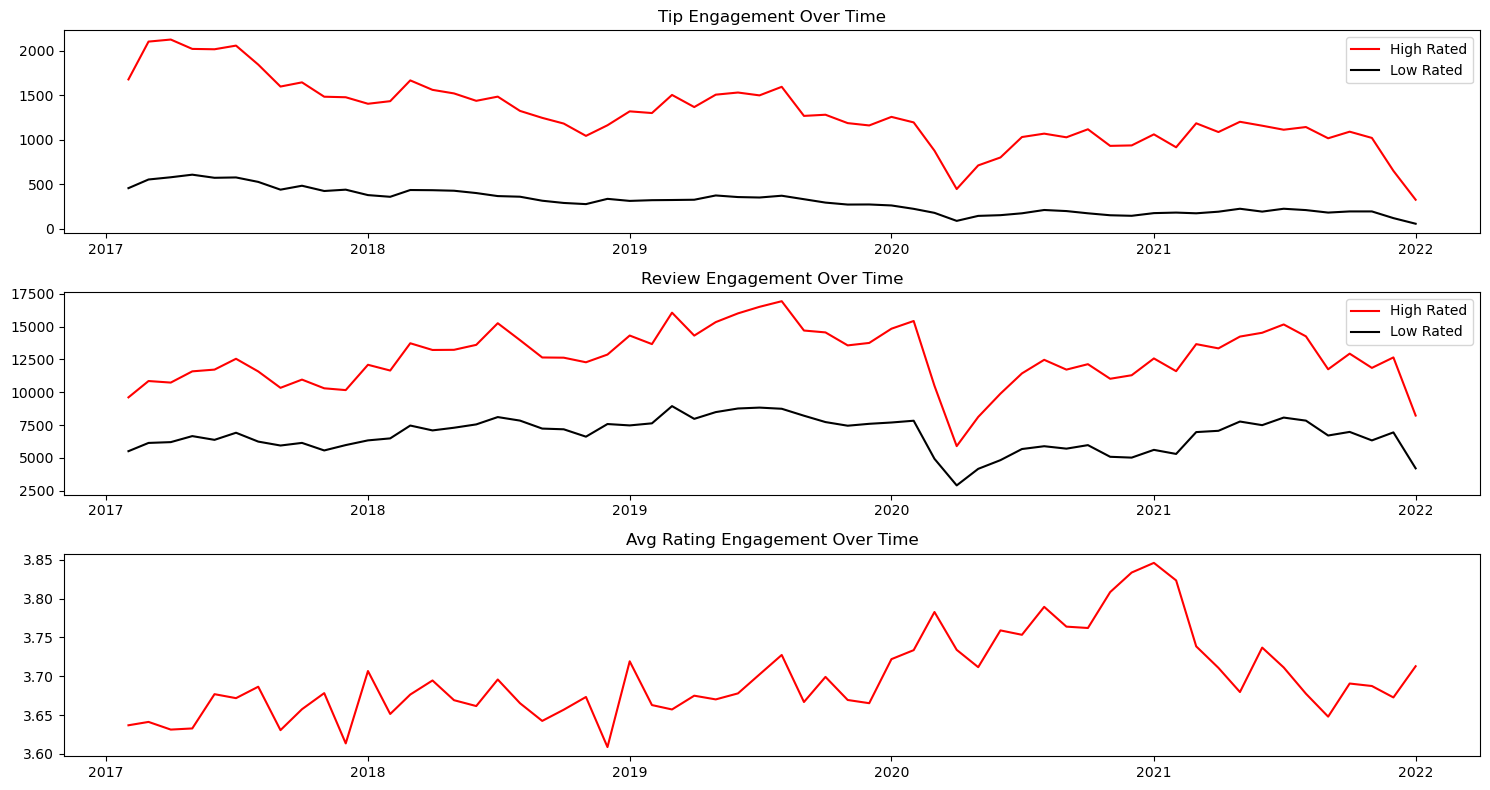

In [90]:
plt.figure(figsize=(15,8))
plt.subplot(3,1,1)
plt.title('Tip Engagement Over Time')
plt.plot(high_rated_engagement['month_year'], high_rated_engagement['tip_count'], label= 'High Rated', color = 'red')
plt.plot(low_rated_engagement['month_year'], low_rated_engagement['tip_count'], label= 'Low Rated', color = 'black')
plt.legend()
plt.subplot(3,1,2)
plt.title('Review Engagement Over Time')
plt.plot(high_rated_engagement['month_year'], high_rated_engagement['review_count'], label= 'High Rated', color = 'red')
plt.plot(low_rated_engagement['month_year'], low_rated_engagement['review_count'], label= 'Low Rated', color = 'black')
plt.legend()
plt.subplot(3,1,3)
plt.title('Avg Rating Engagement Over Time')
plt.plot(time_rating['month_year'], time_rating['avg_rating'], color = 'red')
plt.tight_layout()
plt.show()

##### Insights
##### Higher ratings = significantly more engagement.

##### 2020 shows a strong disruption in activity.

##### User sentiment (ratings) remains fairly stable, even when engagement changes.

In [92]:
#Sentimantal analysis
#how does the staement of reviews and tips (useful, funny, cool) correlate with the sucess matrix of restaurants?

sentiment_df = pd.read_sql_query(f"""Select b.business_id, Avg(b.stars) as avg_rating, sum(b.review_count) as review_count,
    SUM(s.useful_count) as useful_count,
    SUM(s.funny_count) as funny_count,
    SUM(s.cool_count) as cool_count
from (
    Select business_id,
    sum(useful) as useful_count,
    sum(funny) as funny_count, 
    sum(cool) as cool_count
from
    review
group by business_id) as s
join business as b on b.business_id = s.business_id
where b.business_id in {tuple(business_id['business_id'])}
group by b.business_id
order by review_count""",conn)

sentiment_df = remove_outliers(sentiment_df,'review_count')
sentiment_df = remove_outliers(sentiment_df, 'useful_count')
sentiment_df = remove_outliers(sentiment_df, 'cool_count')
sentiment_df = remove_outliers(sentiment_df, 'funny_count')

In [93]:
sentiment_df

,business_id,avg_rating,review_count,useful_count,funny_count,cool_count
0,-2CPhK6ik9ZBgFX_F-dkxQ,2.0,5,3,5,3
1,-3ArWZfDjfab8qVHf3WVtg,4.0,5,18,3,2
2,-4lNMmoW7gRxkH0c2dfXfA,4.0,5,1,0,0
3,-7UDKbg_8TL4LVuYR6Ooyw,3.0,5,3,0,2
4,-AzaeuPwxqFO4SMSKjbuCw,3.0,5,5,0,0
...,...,...,...,...,...,...
29627,radib3GHt_Up9-zhUjM1ew,3.5,175,128,29,21
29633,17AnbEkqAiE66YFTDYFvgw,2.5,176,110,25,25
29652,ZNZcptwIHne1PDcHaMbA-A,4.0,176,81,13,29
29664,k8C4zFZDl8GcjIapHCB77w,4.0,176,91,23,29


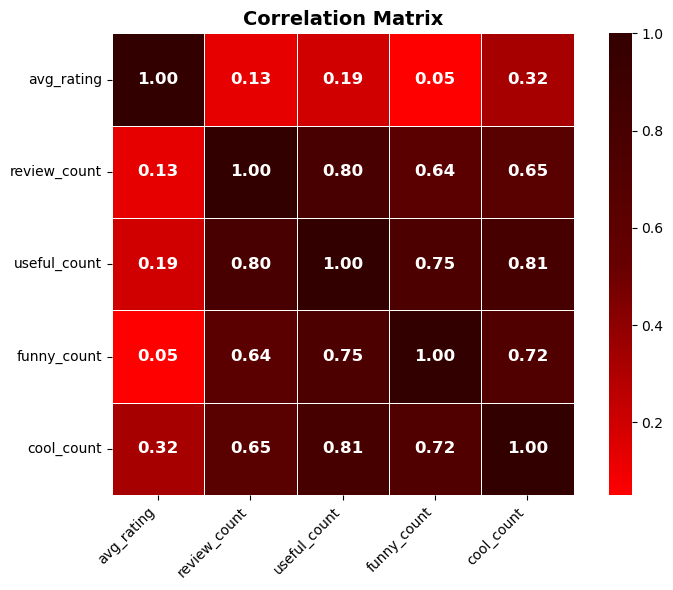

In [94]:
# Select numeric columns
numeric_df = sentiment_df.select_dtypes(include='number')

# Compute correlation
corr_matrix = numeric_df.corr()

# Define a custom colormap (optional, you can tweak colors)
colors = ['#FF0000', '#660000', '#330000']
custom_cmap = LinearSegmentedColormap.from_list("nycmap", colors)

# Plot
plt.figure(figsize=(8,6))
ax = sns.heatmap(
    corr_matrix,
    cmap=custom_cmap,
    cbar=True,
    square=True,
    linewidths=0.5,
    linecolor="white"
)

# Manually overlay text annotations for clarity
for i in range(corr_matrix.shape[0]):
    for j in range(corr_matrix.shape[1]):
        ax.text(
            j + 0.5, i + 0.5, f"{corr_matrix.iloc[i,j]:.2f}",
            ha="center", va="center",
            color="white", fontsize=12, fontweight="bold"
        )

plt.title("Correlation Matrix", fontsize=14, fontweight="bold")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


##### Restaurants with more reviews tends to recive more votes and more community interation

In [80]:
## is there any difference between elite user or non elite users?
elite_df = pd.read_sql_query("""Select elite, 
    Count(*) as num_users, 
    sum(review_count) as total_review_count
from 
    (Select 
            case 
                when elite = '' then 'Non Elite'
                else 'Elite'
            end as elite, 
            u.review_count
    from 
        user u) as user_elite
group by elite;
    """,conn)

In [81]:
elite_df

,elite,num_users,total_review_count
0,Elite,91198,20484441
1,Non Elite,1896699,26021235


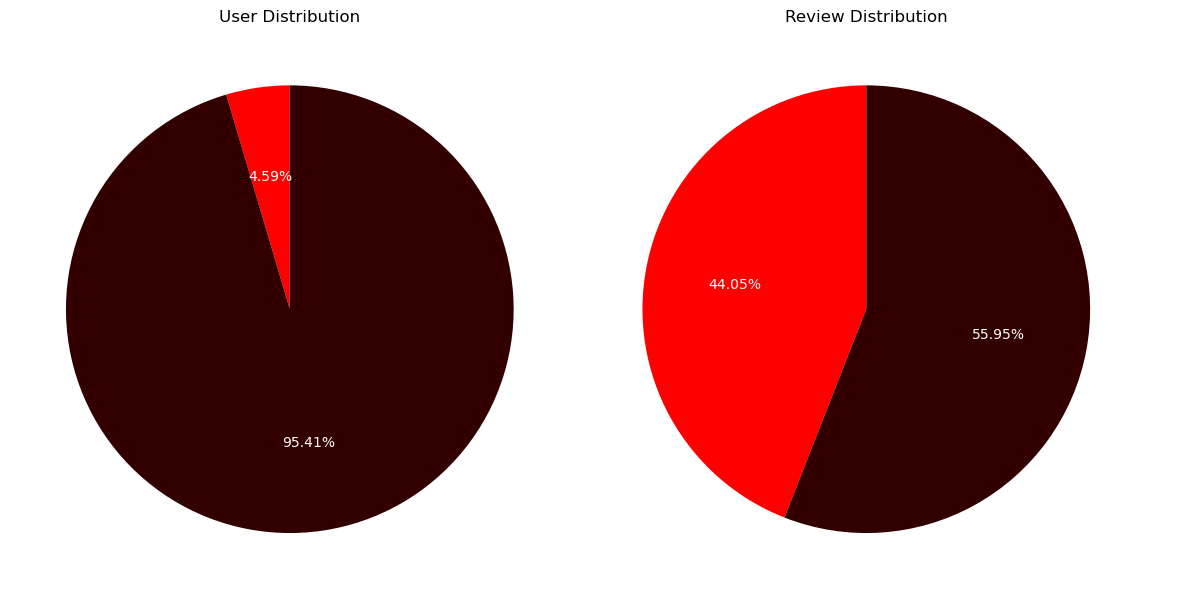

In [100]:

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(12,6))

# Pie chart for user distribution
axes[0].pie(
    elite_df['num_users'],
    labels=elite_df['elite'],
    autopct='%1.2f%%',
    startangle=90,
    colors=['#FF0000', '#330000'],
    textprops={'color':'white'} )
axes[0].set_title('User Distribution')


# Pie chart for review distribution
axes[1].pie(elite_df['total_review_count'], labels=elite_df['elite'], autopct='%1.2f%%', startangle=90, colors=['#FF0000','#330000'],textprops={'color':'white'})
axes[1].set_title('Review Distribution')

plt.tight_layout()
plt.show()


##### Insights Elite users tiny minorities but they contributes majors of reviews related to their count -- hence they are more effective as per users.

In [83]:
# what are the busiest hours for restauranst?

# Reviews by hour
review_engagement = pd.read_sql_query("""
    SELECT CAST(strftime('%H', date) AS INTEGER) AS hour,
           COUNT(*) AS review_count
    FROM review
    GROUP BY hour;
""", conn)

# Tips by hour
tip_engagement = pd.read_sql_query("""
    SELECT CAST(strftime('%H', date) AS INTEGER) AS hour,
           COUNT(*) AS tip_count
    FROM tip
    GROUP BY hour;
""", conn)

# Check-ins by hour
checkin = pd.read_sql_query("SELECT date FROM checkin", conn)

checkin_hours = []
for i in checkin['date']:
    for j in i.split(','):
        checkin_hours.append(
            int(datetime.strptime(j.strip(), "%Y-%m-%d %H:%M:%S").strftime("%H"))
        )

# Build DataFrame with proper column names
checkin_engagement = (
    pd.DataFrame(checkin_hours, columns=['hour'])
      .groupby('hour')
      .size()
      .reset_index(name='checkin_count')
)


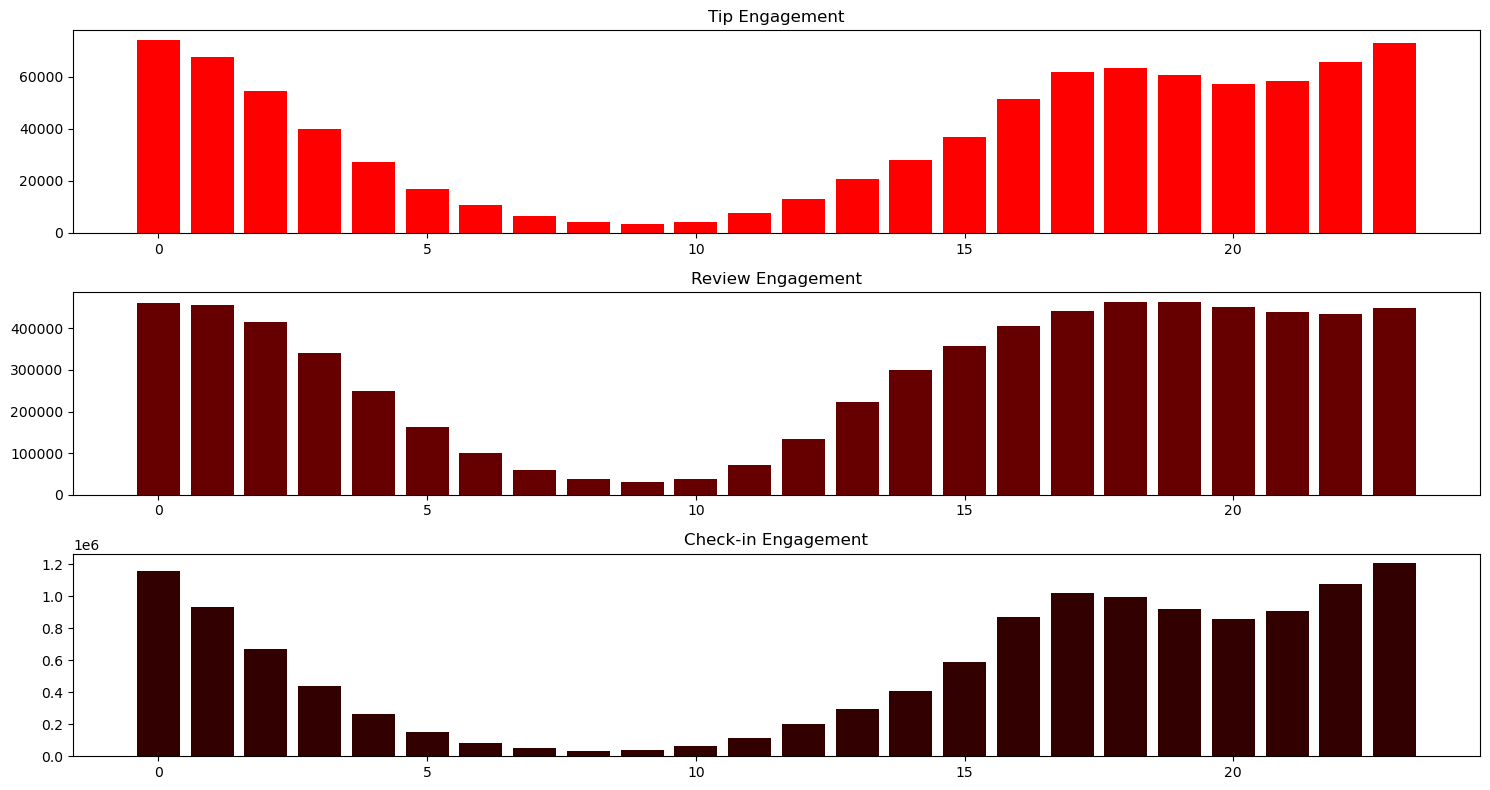

In [102]:
#Plot the graph using Tip_engagement, User_Engagement and Checkin_Engagement
plt.figure(figsize=(15,8))

# Tip Engagement
plt.subplot(3,1,1)
plt.title("Tip Engagement")
plt.bar(tip_engagement['hour'], tip_engagement['tip_count'], color='#FF0000')

# Review Engagement
plt.subplot(3,1,2)
plt.title("Review Engagement")
plt.bar(review_engagement['hour'], review_engagement['review_count'], color='#660000')

# Check-in Engagement
plt.subplot(3,1,3)
plt.title("Check-in Engagement")
plt.bar(checkin_engagement['hour'], checkin_engagement['checkin_count'], color='#330000')

plt.tight_layout()
plt.show()


##### Peak engagement hours occurs during lunch and dinner.

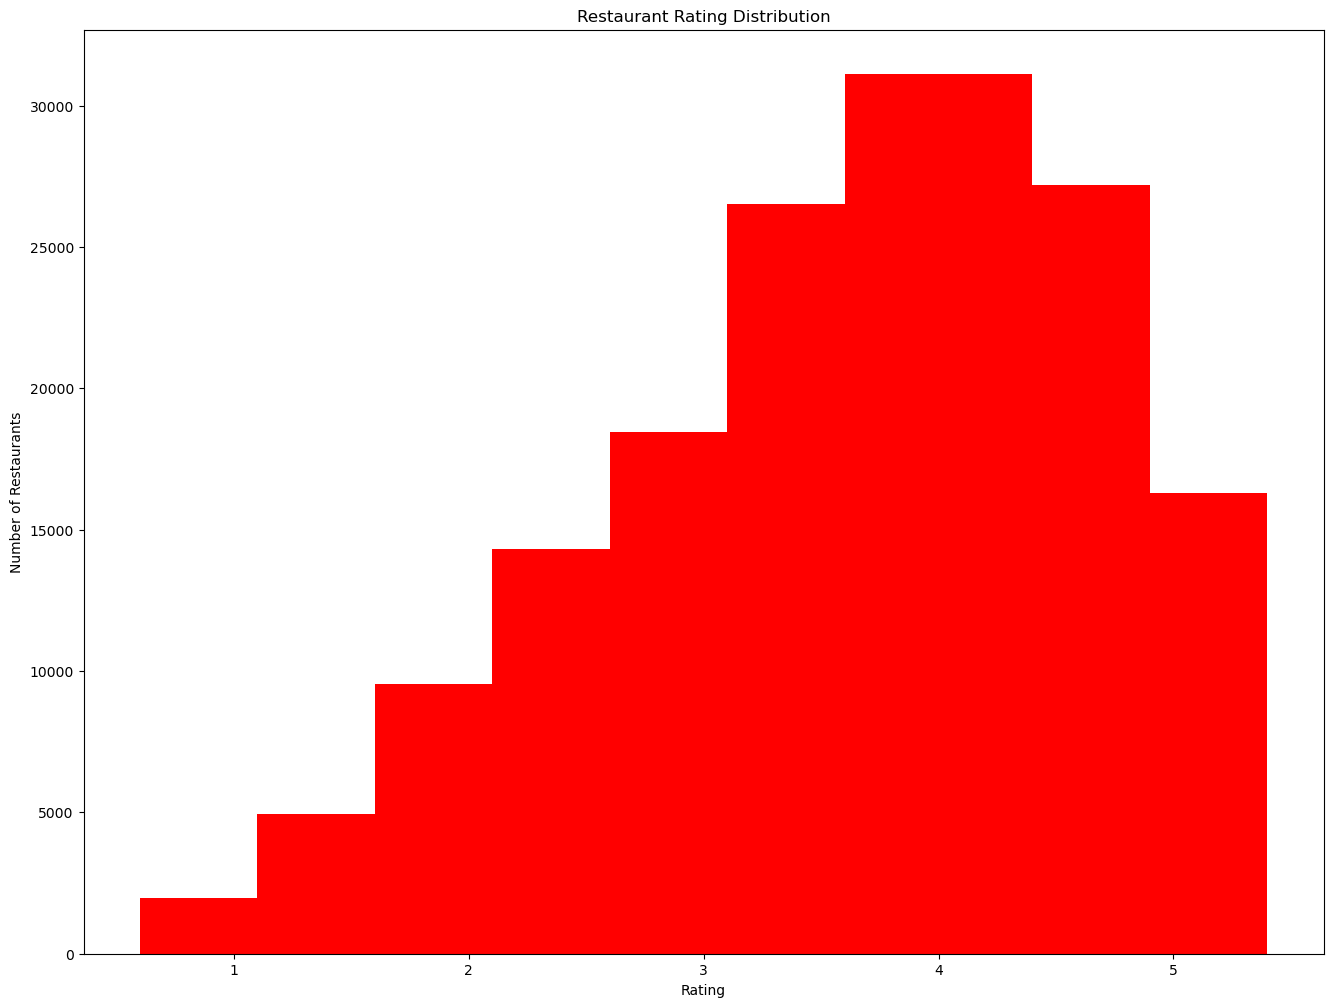

In [105]:
## Rating Distribution Chart
query = """
SELECT stars, COUNT(*) AS restaurant_count
FROM business
GROUP BY stars
ORDER BY stars
"""

df = pd.read_sql(query, conn)

plt.bar(df['stars'], df['restaurant_count'],color = "#FF0000")

plt.xlabel("Rating")
plt.ylabel("Number of Restaurants")
plt.title("Restaurant Rating Distribution")

plt.show()

##### 3 to 4.5 rating gernearly indicates the good sentifectory level.

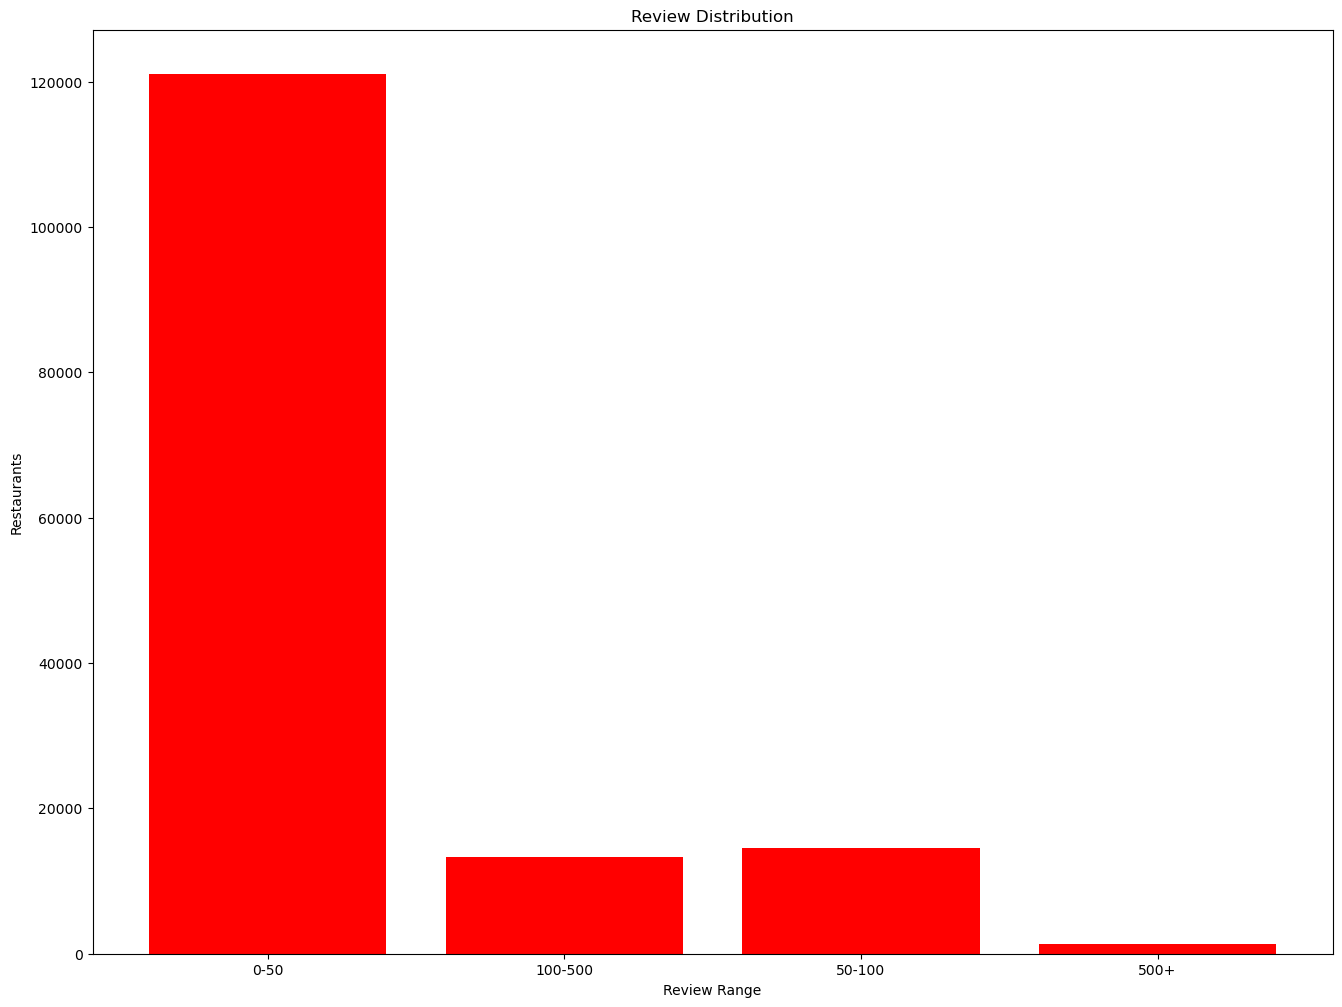

In [106]:
## Review Distribution

query = """SELECT 
    CASE
        WHEN review_count < 50 THEN '0-50'
        WHEN review_count < 100 THEN '50-100'
        WHEN review_count < 500 THEN '100-500'
        ELSE '500+'
    END AS review_range,
    COUNT(*) AS restaurant_count
FROM business
GROUP BY review_range;"""

df = pd.read_sql(query, conn)

plt.bar(df['review_range'], df['restaurant_count'],color = "#FF0000")

plt.xlabel("Review Range")
plt.ylabel("Restaurants")
plt.title("Review Distribution")

plt.show()

##### most of the restaurants having 0-50 they are newly lauched restaurant and highly popular restaurant having more than 500 review count.

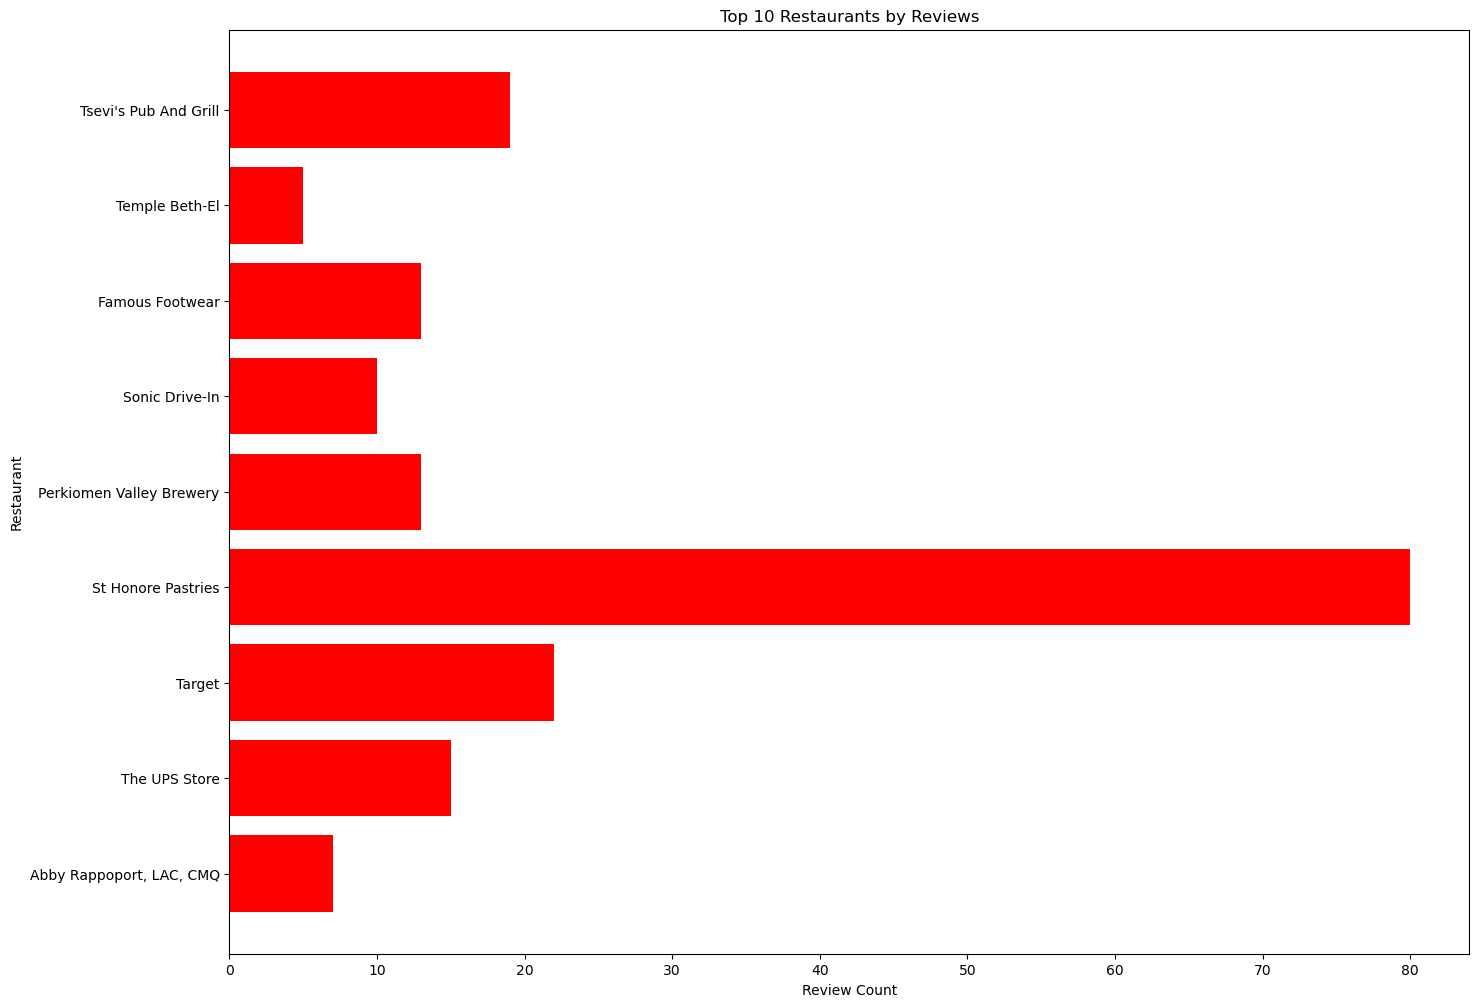

In [107]:
## Top Rasturants
query = """Select name, review_count from business limit 10"""
df = pd.read_sql_query(query,conn)
df = pd.read_sql(query, conn)

plt.barh(df['name'], df['review_count'],color = "#FF0000")

plt.xlabel("Review Count")
plt.ylabel("Restaurant")
plt.title("Top 10 Restaurants by Reviews")

plt.show()

##### A small number of restaurants account for a large share of reviews.

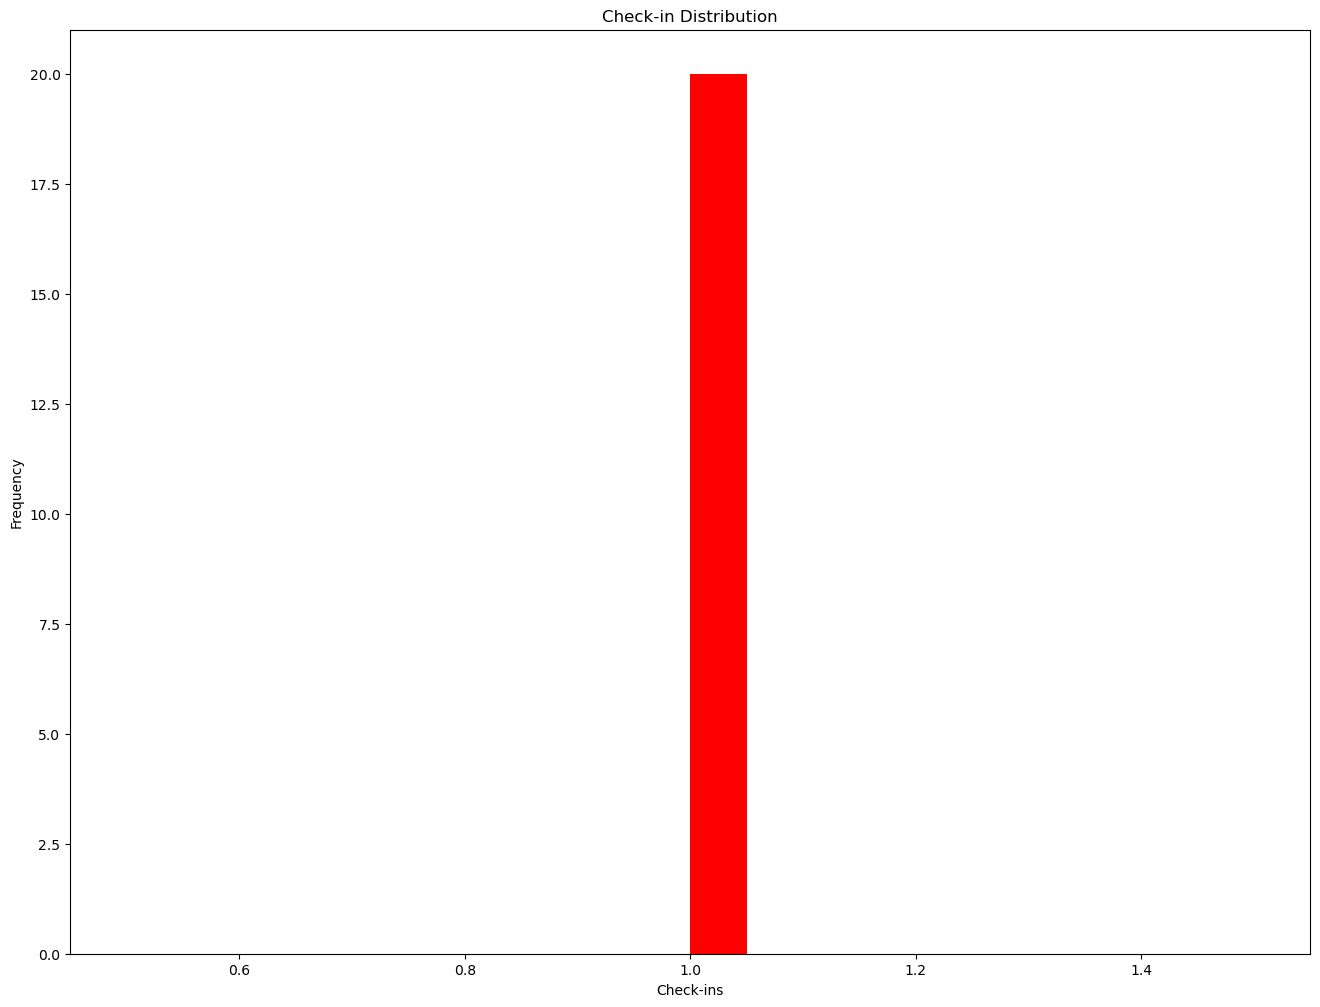

In [108]:
query = """SELECT business_id, COUNT(*) AS total_checkins
FROM checkin
GROUP BY business_id
ORDER BY total_checkins DESC
LIMIT 20;"""
df = pd.read_sql(query, conn)

plt.hist(df['total_checkins'], bins=20,color = "#FF0000")

plt.xlabel("Check-ins")
plt.ylabel("Frequency")
plt.title("Check-in Distribution")

plt.show()